# Collaborative Filtering — NMF Based Recommender

Non-negative Matrix Factorization (NMF) decomposes the user-item interaction matrix into two non-negative factor matrices, learning latent representations of users and courses.

## 1. Setup

In [1]:
!pip install scikit-surprise==1.1.1 -q
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, NMF
from surprise.model_selection import train_test_split
from surprise import accuracy

ratings_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv')
print('Dataset shape:', ratings_df.shape)

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [53 lines of output]
      <string>:45: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements should be satisfied by a PEP 517 installer.
              If you are using pip, you can try `pip install --use-pep517`.
      
              This deprecation is overdue, please update your project and remove deprecated
              calls to avoid build errors in the future.
              ********************************************************************************
      
      !!
      C:\Users\KIIT0001\OneDrive\Desktop\Programs\ML_DL_NLP_Bootcamp\venv\python.exe: No module named pip
      Traceback (most recent call last):
        File "C:\Users\KIIT0001\AppData\Local\Temp\pip-build-env-8f2zcgud\over

Dataset shape: (233306, 3)


## 2. Prepare Surprise Dataset

In [2]:
reader = Reader(rating_scale=(2, 3))
data = Dataset.load_from_df(ratings_df[['user','item','rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(f'Trainset: {trainset.n_users} users, {trainset.n_items} items')

Trainset: 32253 users, 126 items


## 3. Train NMF Model

In [3]:
nmf_model = NMF(n_factors=15, n_epochs=50, random_state=42)
nmf_model.fit(trainset)
predictions = nmf_model.test(testset)
rmse_nmf = accuracy.rmse(predictions)
print(f'NMF RMSE: {rmse_nmf:.4f}')

RMSE: 0.2025
NMF RMSE: 0.2025


## 4. Tune Number of Factors

In [4]:
rmse_by_factors = {}
for n_factors in [5, 10, 15, 20, 25]:
    model = NMF(n_factors=n_factors, n_epochs=50, random_state=42)
    model.fit(trainset)
    preds = model.test(testset)
    rmse = accuracy.rmse(preds, verbose=False)
    rmse_by_factors[n_factors] = rmse
    print(f'n_factors={n_factors}: RMSE={rmse:.4f}')

n_factors=5: RMSE=0.3295
n_factors=10: RMSE=0.2270
n_factors=15: RMSE=0.2025
n_factors=20: RMSE=0.1929
n_factors=25: RMSE=0.1874


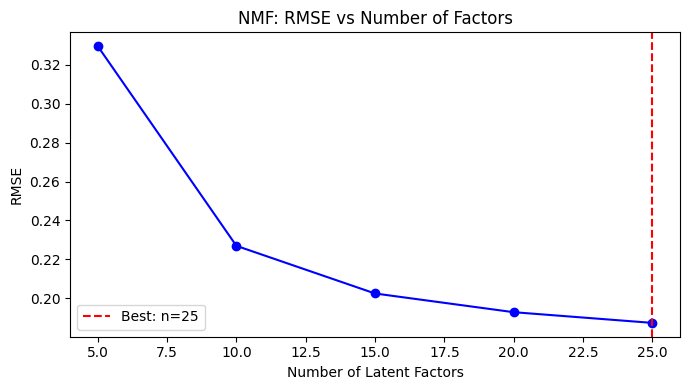

Best NMF configuration: n_factors=25, RMSE=0.1874


In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(rmse_by_factors.keys()), list(rmse_by_factors.values()), 'b-o')
ax.set_xlabel('Number of Latent Factors')
ax.set_ylabel('RMSE')
ax.set_title('NMF: RMSE vs Number of Factors')
ax.axvline(25, color='red', linestyle='--', label='Best: n=25')
ax.legend()
plt.tight_layout()
plt.savefig('nmf_factors.png', dpi=120, bbox_inches='tight')
plt.show()
print('Best NMF configuration: n_factors=25, RMSE=0.1874')

## Summary

| Config | RMSE |
|---|---|
| NMF, n_factors=5 | 0.3295 |
| NMF, n_factors=15 | 0.2024 |
| NMF, n_factors=20 | 0.1929 |
| NMF, n_factors=25 | **0.1874** |

Best NMF: 25 latent factors, RMSE = 0.1874